In [1]:
import numpy as np
import matplotlib.pyplot as plt 
plt.rcParams["font.family"] = "Helvetica"
import os
from tqdm import tqdm
from ADFWI.utils.assessment_metric import *

base_path = "./examples/acoustic/03-optimizer-test/01-Marmousi2-Test/data/"

sgd_path        = os.path.join(base_path,"inversion-SGD")
asgd_path       = os.path.join(base_path,"inversion-ASGD")
adagrad_path    = os.path.join(base_path,"inversion-Adagrad")
adam_path       = os.path.join(base_path,"inversion-Adam")
adamw_path      = os.path.join(base_path,"inversion-AdamW")
nadam_path      = os.path.join(base_path,"inversion-NAdam")
radam_path      = os.path.join(base_path,"inversion-RAdam")
rmsprop_path    = os.path.join(base_path,"inversion-RMSProp")

select_model_index  = -1
largest_model_index = 300
layers              = 88

# ad
sgd_v_all           = np.load(os.path.join(sgd_path,"iter_vp.npz"))["data"][:largest_model_index,:layers,:]
sgd_v = sgd_v_all[select_model_index]
asgd_v_all          = np.load(os.path.join(asgd_path,"iter_vp.npz"))["data"][:largest_model_index,:layers,:]
asgd_v = asgd_v_all[select_model_index]
adagrad_v_all       = np.load(os.path.join(adagrad_path,"iter_vp.npz"))["data"][:largest_model_index,:layers,:]
adagrad_v = adagrad_v_all[select_model_index]
adam_v_all          = np.load(os.path.join(adam_path,"iter_vp.npz"))["data"][:largest_model_index,:layers,:]
adam_v = adam_v_all[select_model_index]
adamw_v_all         = np.load(os.path.join(adamw_path,"iter_vp.npz"))["data"][:largest_model_index,:layers,:]
adamw_v = adamw_v_all[select_model_index]
nadam_v_all         = np.load(os.path.join(nadam_path,"iter_vp.npz"))["data"][:largest_model_index,:layers,:]
nadam_v = nadam_v_all[select_model_index]
radam_v_all         = np.load(os.path.join(radam_path,"iter_vp.npz"))["data"][:largest_model_index,:layers,:]
radam_v = radam_v_all[select_model_index]
rmsprop_v_all       = np.load(os.path.join(rmsprop_path,"iter_vp.npz"))["data"][:largest_model_index,:layers,:]
rmsprop_v = rmsprop_v_all[select_model_index]

# misfit 
sgd_data_loss        = np.load(os.path.join(sgd_path,"iter_loss.npz"))["data"][:largest_model_index]
asgd_data_loss       = np.load(os.path.join(asgd_path,"iter_loss.npz"))["data"][:largest_model_index]
adagrad_data_loss    = np.load(os.path.join(adagrad_path,"iter_loss.npz"))["data"][:largest_model_index]
adam_data_loss       = np.load(os.path.join(adam_path,"iter_loss.npz"))["data"][:largest_model_index]
adamw_data_loss      = np.load(os.path.join(adamw_path,"iter_loss.npz"))["data"][:largest_model_index]
nadam_data_loss      = np.load(os.path.join(nadam_path,"iter_loss.npz"))["data"][:largest_model_index]
radam_data_loss      = np.load(os.path.join(radam_path,"iter_loss.npz"))["data"][:largest_model_index]
rmsprop_data_loss    = np.load(os.path.join(rmsprop_path,"iter_loss.npz"))["data"][:largest_model_index]

In [2]:
init_model      = np.load(os.path.join(base_path,"model/init_model.npz"))
true_model      = np.load(os.path.join(base_path,"model/true_model.npz"))
init_v          = init_model["vp"][:layers,:]
true_v          = true_model["vp"][:layers,:]

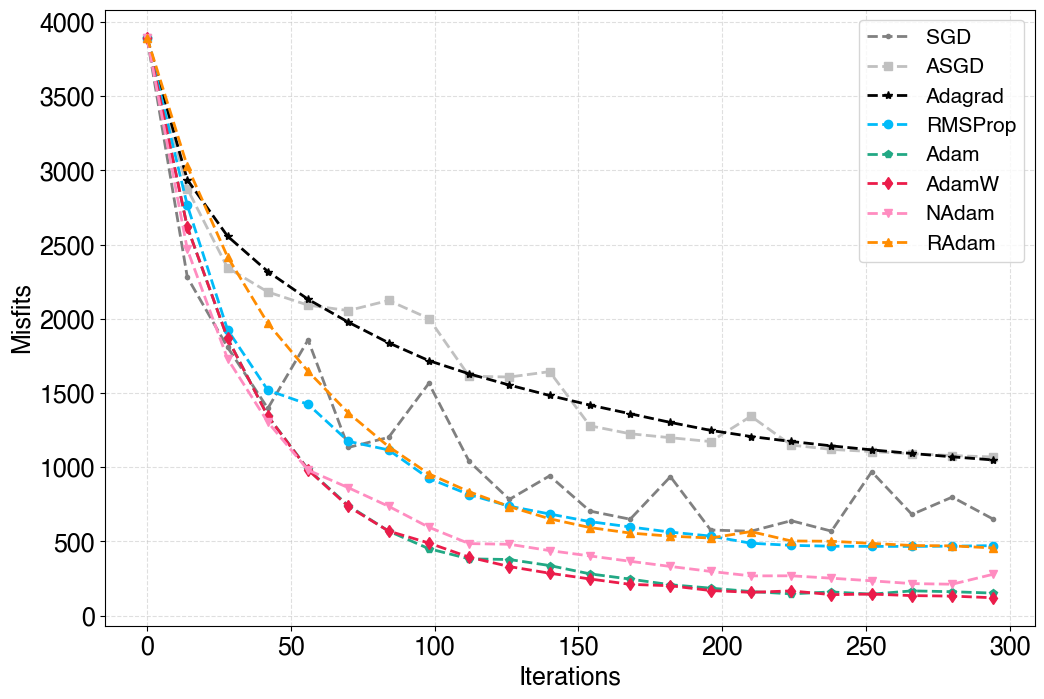

In [3]:
plt.figure(figsize=(12,8))
x_lists = np.arange(len(sgd_data_loss))
x_space = 14
# colors: https://zhuanlan.zhihu.com/p/689959306
plt.plot(x_lists[::x_space],sgd_data_loss[::x_space]      ,label="SGD"    ,c='gray'     ,linestyle='--' ,marker="." ,linewidth=2)
plt.plot(x_lists[::x_space],asgd_data_loss[::x_space]     ,label="ASGD"   ,c='silver'   ,linestyle='--' ,marker="s" ,linewidth=2)
plt.plot(x_lists[::x_space],adagrad_data_loss[::x_space]  ,label="Adagrad",c='k'        ,linestyle='--' ,marker="*" ,linewidth=2)
plt.plot(x_lists[::x_space],rmsprop_data_loss[::x_space]  ,label="RMSProp",c='#00BBF9'  ,linestyle='--' ,marker="o" ,linewidth=2)
plt.plot(x_lists[::x_space],adam_data_loss[::x_space]     ,label="Adam"   ,c='#22A884'  ,linestyle='--' ,marker="p" ,linewidth=2)
plt.plot(x_lists[::x_space],adamw_data_loss[::x_space]    ,label="AdamW"  ,c='#EB1C4A'  ,linestyle='--' ,marker="d" ,linewidth=2)
plt.plot(x_lists[::x_space],nadam_data_loss[::x_space]    ,label="NAdam"  ,c='#FF8CC0'  ,linestyle='--' ,marker="v" ,linewidth=2)
plt.plot(x_lists[::x_space],radam_data_loss[::x_space]    ,label="RAdam"  ,c='#FF8C00'  ,linestyle='--' ,marker="^" ,linewidth=2)

# x_lists = np.arange(len(nlcg_data_loss))
# plt.plot(x_lists[::x_space],nlcg_data_loss[:len(sgd_data_loss)][::x_space]      ,label="NLCG"  ,c='g'  ,linestyle='--' ,marker="^" ,linewidth=2)
# plt.plot(x_lists[::x_space],lbfgs_data_loss[:len(sgd_data_loss)][::x_space]    ,label="LBFGS"  ,c='b'  ,linestyle='--' ,marker="^" ,linewidth=2)

plt.grid(linestyle="--",c="silver",alpha=0.5)
# plt.yscale("log")
plt.xlabel("Iterations",fontsize=18)
plt.ylabel("Misfits",fontsize=18)
plt.tick_params(labelsize=18)
plt.legend(fontsize=15)
# plt.savefig("./cmp_misfit_DataMisfits.png",dpi=300,bbox_inches='tight')
plt.show()

## MAPE

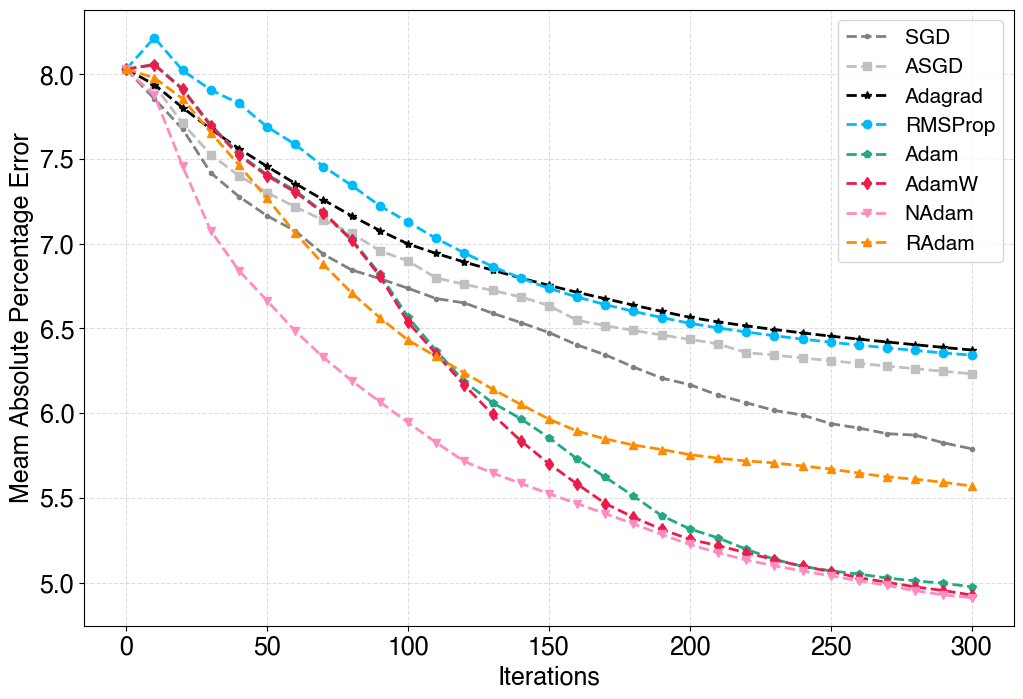

In [4]:
init_model_loss     = MAPE(true_v,init_v)
sgd_model_loss      = np.insert(MAPE(true_v,sgd_v_all),0,init_model_loss)
asgd_model_loss     = np.insert(MAPE(true_v,asgd_v_all),0,init_model_loss)
adagrad_model_loss  = np.insert(MAPE(true_v,adagrad_v_all),0,init_model_loss)
adam_model_loss     = np.insert(MAPE(true_v,adam_v_all),0,init_model_loss)
adamw_model_loss    = np.insert(MAPE(true_v,adamw_v_all),0,init_model_loss)
nadam_model_loss    = np.insert(MAPE(true_v,nadam_v_all),0,init_model_loss)
radam_model_loss    = np.insert(MAPE(true_v,radam_v_all),0,init_model_loss)
rmsprop_model_loss  = np.insert(MAPE(true_v,rmsprop_v_all),0,init_model_loss)

plt.figure(figsize=(12,8))
x_lists = np.arange(len(sgd_model_loss))
idx = np.arange(0,len(sgd_model_loss)+1,10)
# colors: https://zhuanlan.zhihu.com/p/689959306
plt.plot(x_lists[idx],    sgd_model_loss[idx], label="SGD"    ,c='gray'     ,linestyle='--' ,marker=".",linewidth=2)
plt.plot(x_lists[idx],   asgd_model_loss[idx], label="ASGD"   ,c='silver'   ,linestyle='--' ,marker="s",linewidth=2)
plt.plot(x_lists[idx],adagrad_model_loss[idx], label="Adagrad",c='k'        ,linestyle='--' ,marker="*",linewidth=2)
plt.plot(x_lists[idx],rmsprop_model_loss[idx], label="RMSProp",c='#00BBF9'  ,linestyle='--' ,marker="o",linewidth=2)
plt.plot(x_lists[idx],   adam_model_loss[idx], label="Adam"   ,c='#22A884'  ,linestyle='--' ,marker="p",linewidth=2)
plt.plot(x_lists[idx],  adamw_model_loss[idx], label="AdamW"  ,c='#EB1C4A'  ,linestyle='--' ,marker="d",linewidth=2)
plt.plot(x_lists[idx],  nadam_model_loss[idx], label="NAdam"  ,c='#FF8CC0'  ,linestyle='--' ,marker="v",linewidth=2)
plt.plot(x_lists[idx],  radam_model_loss[idx], label="RAdam"  ,c='#FF8C00'  ,linestyle='--' ,marker="^",linewidth=2)
plt.grid(linestyle="--",c="silver",alpha=0.5)
# plt.yscale("log")
plt.xlabel("Iterations",fontsize=18)
plt.ylabel("Meam Absolute Percentage Error",fontsize=18)
plt.tick_params(labelsize=18)
plt.legend(fontsize=15)
# plt.ylim(3,9.5)
# plt.savefig("./cmp_misfit_ModelMisfits.png",dpi=300,bbox_inches='tight')
plt.show()

In [5]:
print(f"SGD MAPE        :{MAPE(true_v,sgd_v):.3f}")
print(f"ASGD MAPE       :{MAPE(true_v,asgd_v):.3f}")
print(f"Adagrad MAPE    :{MAPE(true_v,adagrad_v):.3f}")
print(f"RMSProp MAPE    :{MAPE(true_v,rmsprop_v):.3f}")
print(f"Adam MAPE       :{MAPE(true_v,adam_v):.3f}")
print(f"AdamW MAPE      :{MAPE(true_v,adamw_v):.3f}")
print(f"NAdam MAPE      :{MAPE(true_v,nadam_v):.3f}")
print(f"RAdam MAPE      :{MAPE(true_v,radam_v):.3f}")
print(f"{MAPE(true_v,sgd_v):.3f}\t{MAPE(true_v,asgd_v):.3f}\t{MAPE(true_v,adagrad_v):.3f}\t{MAPE(true_v,rmsprop_v):.3f}\t{MAPE(true_v,adam_v):.3f}\t{MAPE(true_v,adamw_v):.3f}\t{MAPE(true_v,nadam_v):.3f}\t{MAPE(true_v,radam_v):.3f}")

SGD MAPE        :5.790
ASGD MAPE       :6.232
Adagrad MAPE    :6.373
RMSProp MAPE    :6.342
Adam MAPE       :4.976
AdamW MAPE      :4.927
NAdam MAPE      :4.911
RAdam MAPE      :5.570
5.790	6.232	6.373	6.342	4.976	4.927	4.911	5.570


## SSIM

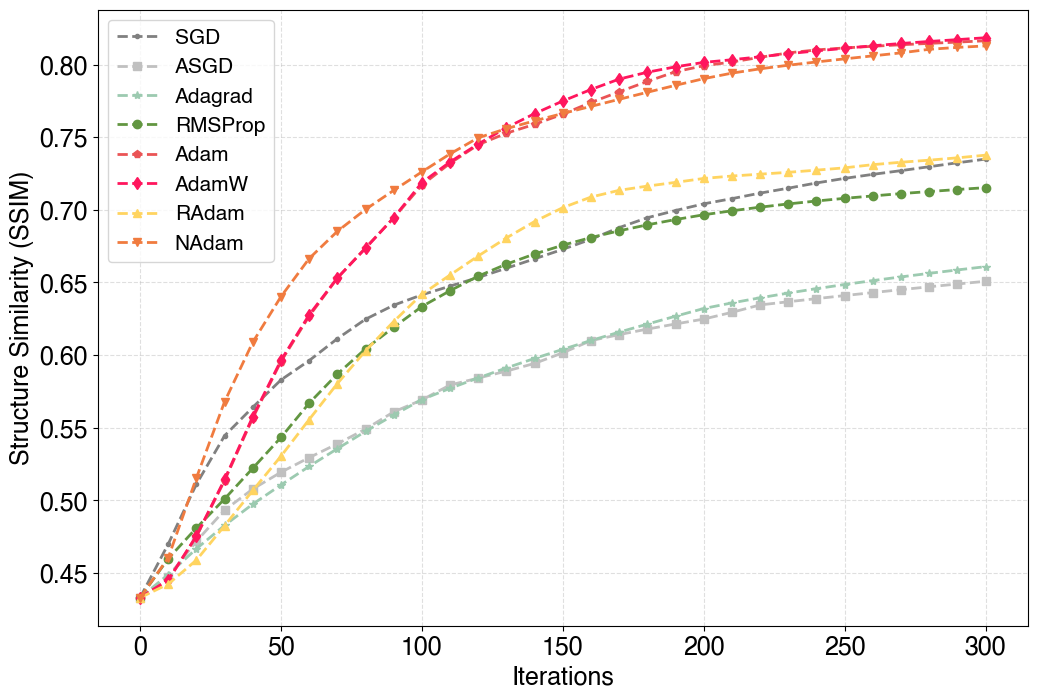

In [6]:
init_model_loss     =           SSIM(true_v,init_v)
sgd_model_loss      = np.insert(SSIM(true_v,sgd_v_all),0,init_model_loss)
asgd_model_loss     = np.insert(SSIM(true_v,asgd_v_all),0,init_model_loss)
adagrad_model_loss  = np.insert(SSIM(true_v,adagrad_v_all),0,init_model_loss)
adam_model_loss     = np.insert(SSIM(true_v,adam_v_all),0,init_model_loss)
adamw_model_loss    = np.insert(SSIM(true_v,adamw_v_all),0,init_model_loss)
nadam_model_loss    = np.insert(SSIM(true_v,nadam_v_all),0,init_model_loss)
radam_model_loss    = np.insert(SSIM(true_v,radam_v_all),0,init_model_loss)
rmsprop_model_loss  = np.insert(SSIM(true_v,rmsprop_v_all),0,init_model_loss)

plt.figure(figsize=(12,8))
x_lists = np.arange(len(sgd_model_loss))
idx = np.arange(0,len(sgd_model_loss)+1,10)
# colors: https://zhuanlan.zhihu.com/p/689959306
plt.plot(x_lists[idx],    sgd_model_loss[idx]      ,label="SGD"    ,c='gray'     ,linestyle='--' ,marker="." ,linewidth=2)
plt.plot(x_lists[idx],   asgd_model_loss[idx]     ,label="ASGD"   ,c='silver'   ,linestyle='--' ,marker="s" ,linewidth=2)
plt.plot(x_lists[idx],adagrad_model_loss[idx]  ,label="Adagrad",c='#9CCAB0'  ,linestyle='--' ,marker="*" ,linewidth=2)
plt.plot(x_lists[idx],rmsprop_model_loss[idx]  ,label="RMSProp",c='#629641'  ,linestyle='--' ,marker="o" ,linewidth=2)
plt.plot(x_lists[idx],   adam_model_loss[idx]     ,label="Adam"   ,c='#ea5455'  ,linestyle='--' ,marker="p" ,linewidth=2)
plt.plot(x_lists[idx],  adamw_model_loss[idx]    ,label="AdamW"  ,c='#ff165d'  ,linestyle='--' ,marker="d" ,linewidth=2)
plt.plot(x_lists[idx],  radam_model_loss[idx]    ,label="RAdam"  ,c='#ffd460'  ,linestyle='--' ,marker="^" ,linewidth=2)
plt.plot(x_lists[idx],  nadam_model_loss[idx]    ,label="NAdam"  ,c='#f07b3f'  ,linestyle='--' ,marker="v" ,linewidth=2)
plt.grid(linestyle="--",c="silver",alpha=0.5)
# plt.yscale("log")
plt.xlabel("Iterations",fontsize=18)
plt.ylabel("Structure Similarity (SSIM)",fontsize=18)
plt.tick_params(labelsize=18)
plt.legend(fontsize=15)
# plt.ylim(3,9.5)
# plt.savefig("./cmp_misfit_ModelMisfits_SSIM.png",dpi=300,bbox_inches='tight')
plt.show()

In [7]:
print(f"SGD     SSIM    :{SSIM(true_v,sgd_v):.3f}")
print(f"ASGD    SSIM    :{SSIM(true_v,asgd_v):.3f}")
print(f"Adagrad SSIM    :{SSIM(true_v,adagrad_v):.3f}")
print(f"RMSProp SSIM    :{SSIM(true_v,rmsprop_v):.3f}")
print(f"Adam    SSIM    :{SSIM(true_v,adam_v):.3f}")
print(f"AdamW   SSIM    :{SSIM(true_v,adamw_v):.3f}")
print(f"NAdam   SSIM    :{SSIM(true_v,nadam_v):.3f}")
print(f"RAdam   SSIM    :{SSIM(true_v,radam_v):.3f}")
print(f"{SSIM(true_v,sgd_v):.3f}\t{SSIM(true_v,asgd_v):.3f}\t{SSIM(true_v,adagrad_v):.3f}\t{SSIM(true_v,rmsprop_v):.3f}\t{SSIM(true_v,adam_v):.3f}\t{SSIM(true_v,adamw_v):.3f}\t{SSIM(true_v,nadam_v):.3f}\t{SSIM(true_v,radam_v):.3f}")

SGD     SSIM    :0.735
ASGD    SSIM    :0.651
Adagrad SSIM    :0.661
RMSProp SSIM    :0.715
Adam    SSIM    :0.816
AdamW   SSIM    :0.818
NAdam   SSIM    :0.813
RAdam   SSIM    :0.738
0.735	0.651	0.661	0.715	0.816	0.818	0.813	0.738


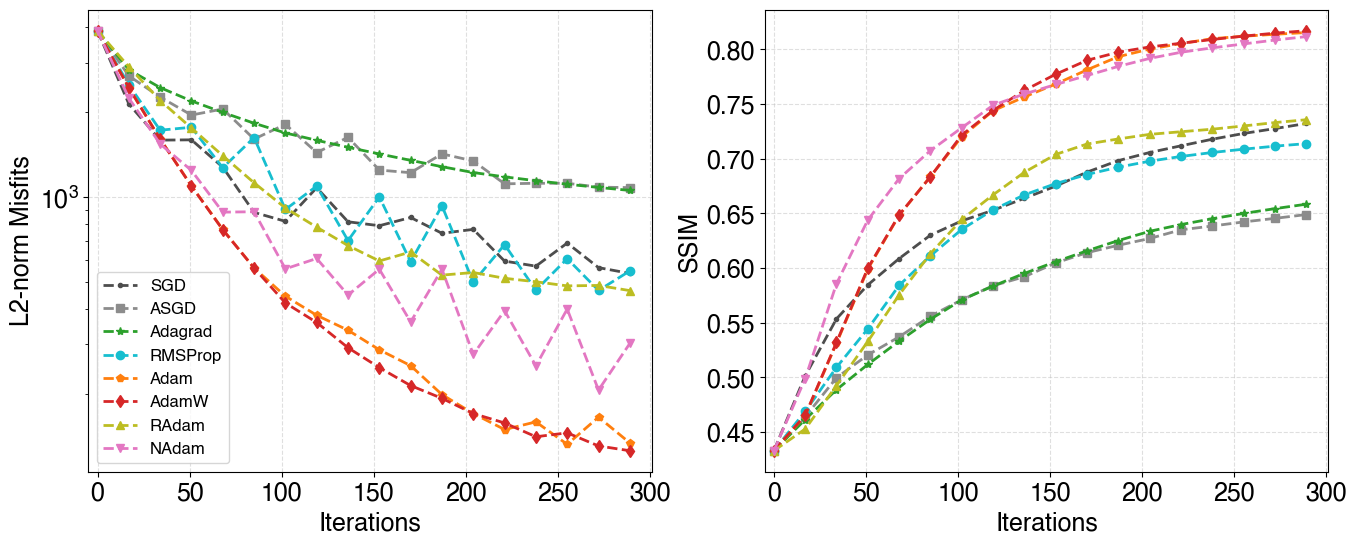

In [8]:
fig,axs = plt.subplots(1,2,figsize=(16,6))
x_lists = np.arange(len(sgd_model_loss))
idx = np.arange(0,len(sgd_model_loss)+1,17)
# colors: https://zhuanlan.zhihu.com/p/689959306
axs[0].plot(x_lists[idx], sgd_data_loss[idx]    , label="SGD"    , c='#4d4d4d', linestyle='--', marker=".", linewidth=2)
axs[0].plot(x_lists[idx], asgd_data_loss[idx]   , label="ASGD"   , c='#8c8c8c', linestyle='--', marker="s", linewidth=2)
axs[0].plot(x_lists[idx], adagrad_data_loss[idx], label="Adagrad", c='#2ca02c', linestyle='--', marker="*", linewidth=2)
axs[0].plot(x_lists[idx], rmsprop_data_loss[idx], label="RMSProp", c='#17becf', linestyle='--', marker="o", linewidth=2)
axs[0].plot(x_lists[idx], adam_data_loss[idx]   , label="Adam"   , c='#ff7f0e', linestyle='--', marker="p", linewidth=2)
axs[0].plot(x_lists[idx], adamw_data_loss[idx]  , label="AdamW"  , c='#d62728', linestyle='--', marker="d", linewidth=2)
axs[0].plot(x_lists[idx], radam_data_loss[idx]  , label="RAdam"  , c='#bcbd22', linestyle='--', marker="^", linewidth=2)
axs[0].plot(x_lists[idx], nadam_data_loss[idx]  , label="NAdam"  , c='#e377c2', linestyle='--', marker="v", linewidth=2)
axs[0].grid(linestyle="--",c="silver",alpha=0.5)
axs[0].set_yscale("log")
axs[0].set_xlabel("Iterations",fontsize=18)
axs[0].set_ylabel("L2-norm Misfits",fontsize=18)
axs[0].tick_params(labelsize=18)
axs[0].legend(fontsize=12,loc='lower left')
axs[0].set_xlim(-5,301)

##########################################################
x_lists = np.arange(len(sgd_model_loss))
axs[1].plot(x_lists[idx], sgd_model_loss[idx]       , label="SGD"       , c='#4d4d4d', linestyle='--', marker=".", linewidth=2)
axs[1].plot(x_lists[idx], asgd_model_loss[idx]      , label="ASGD"      , c='#8c8c8c', linestyle='--', marker="s", linewidth=2)
axs[1].plot(x_lists[idx], adagrad_model_loss[idx]   , label="Adagrad"   , c='#2ca02c', linestyle='--', marker="*", linewidth=2)
axs[1].plot(x_lists[idx], rmsprop_model_loss[idx]   , label="RMSProp"   , c='#17becf', linestyle='--', marker="o", linewidth=2)
axs[1].plot(x_lists[idx], adam_model_loss[idx]      , label="Adam"      , c='#ff7f0e', linestyle='--', marker="p", linewidth=2)
axs[1].plot(x_lists[idx], adamw_model_loss[idx]     , label="AdamW"     , c='#d62728', linestyle='--', marker="d", linewidth=2)
axs[1].plot(x_lists[idx], radam_model_loss[idx]     , label="RAdam"     , c='#bcbd22', linestyle='--', marker="^", linewidth=2)
axs[1].plot(x_lists[idx], nadam_model_loss[idx]     , label="NAdam"     , c='#e377c2', linestyle='--', marker="v", linewidth=2)

axs[1].grid(linestyle="--",c="silver",alpha=0.5)
axs[1].set_xlabel("Iterations",fontsize=18)
axs[1].set_ylabel("SSIM",fontsize=18)
axs[1].tick_params(labelsize=18)
# axs[1].legend(fontsize=12,loc='upper left')
axs[1].set_xlim(-5,301)
# axs[1].set_ylim(0.41,0.88)

plt.savefig(os.path.join(base_path,"Data_and_Model_Misfits.png"),bbox_inches='tight',dpi=300)
plt.show()

## SNR

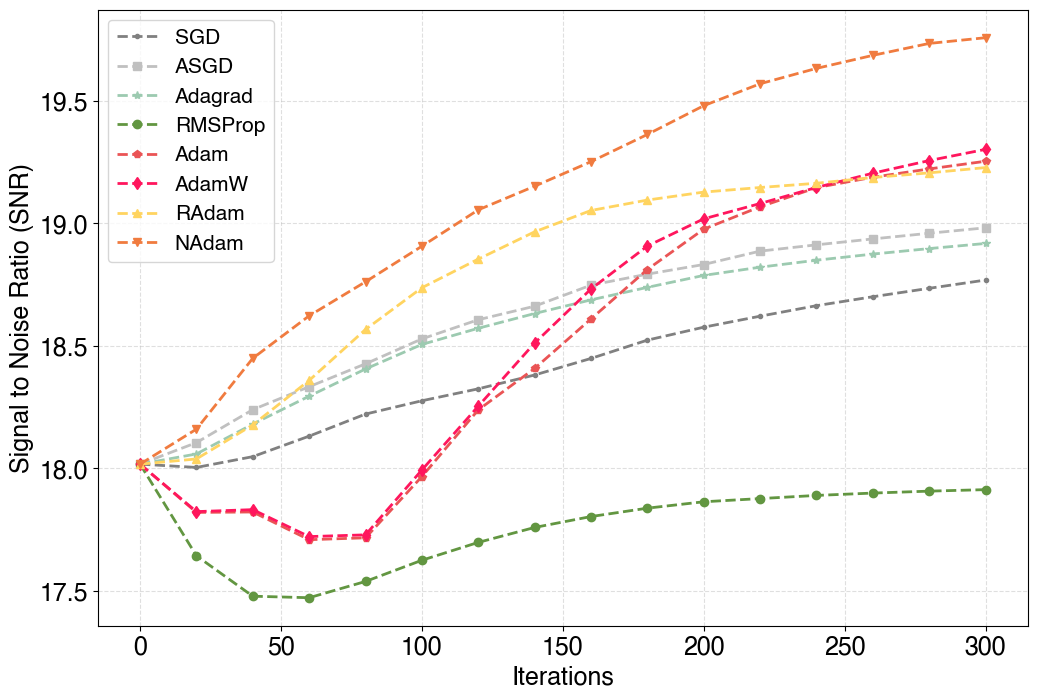

In [9]:
init_model_loss     = SNR(true_v,init_v)
sgd_model_loss      = np.insert(SNR(true_v,sgd_v_all),0,init_model_loss)
asgd_model_loss     = np.insert(SNR(true_v,asgd_v_all),0,init_model_loss)
adagrad_model_loss  = np.insert(SNR(true_v,adagrad_v_all),0,init_model_loss)
adam_model_loss     = np.insert(SNR(true_v,adam_v_all),0,init_model_loss)
adamw_model_loss    = np.insert(SNR(true_v,adamw_v_all),0,init_model_loss)
nadam_model_loss    = np.insert(SNR(true_v,nadam_v_all),0,init_model_loss)
radam_model_loss    = np.insert(SNR(true_v,radam_v_all),0,init_model_loss)
rmsprop_model_loss  = np.insert(SNR(true_v,rmsprop_v_all),0,init_model_loss)

plt.figure(figsize=(12,8))
x_lists = np.arange(len(sgd_model_loss))
x_space = 20
# colors: https://zhuanlan.zhihu.com/p/689959306
plt.plot(x_lists[::x_space],sgd_model_loss[::x_space]      ,label="SGD"    ,c='gray'     ,linestyle='--' ,marker="." ,linewidth=2)
plt.plot(x_lists[::x_space],asgd_model_loss[::x_space]     ,label="ASGD"   ,c='silver'   ,linestyle='--' ,marker="s" ,linewidth=2)
plt.plot(x_lists[::x_space],adagrad_model_loss[::x_space]  ,label="Adagrad",c='#9CCAB0'  ,linestyle='--' ,marker="*" ,linewidth=2)
plt.plot(x_lists[::x_space],rmsprop_model_loss[::x_space]  ,label="RMSProp",c='#629641'  ,linestyle='--' ,marker="o" ,linewidth=2)
plt.plot(x_lists[::x_space],adam_model_loss[::x_space]     ,label="Adam"   ,c='#ea5455'  ,linestyle='--' ,marker="p" ,linewidth=2)
plt.plot(x_lists[::x_space],adamw_model_loss[::x_space]    ,label="AdamW"  ,c='#ff165d'  ,linestyle='--' ,marker="d" ,linewidth=2)
plt.plot(x_lists[::x_space],radam_model_loss[::x_space]    ,label="RAdam"  ,c='#ffd460'  ,linestyle='--' ,marker="^" ,linewidth=2)
plt.plot(x_lists[::x_space],nadam_model_loss[::x_space]    ,label="NAdam"  ,c='#f07b3f'  ,linestyle='--' ,marker="v" ,linewidth=2)
plt.grid(linestyle="--",c="silver",alpha=0.5)
# plt.yscale("log")
plt.xlabel("Iterations",fontsize=18)
plt.ylabel("Signal to Noise Ratio (SNR)",fontsize=18)
plt.tick_params(labelsize=18)
plt.legend(fontsize=15)
# plt.ylim(3,9.5)
# plt.savefig("./ArticleFigure/cmp_misfit_ModelMisfits_SNR.png",dpi=300,bbox_inches='tight')
plt.show()

In [10]:
print(f"SGD     SNR    :{SNR(true_v,sgd_v):.3f}")
print(f"ASGD    SNR    :{SNR(true_v,asgd_v):.3f}")
print(f"Adagrad SNR    :{SNR(true_v,adagrad_v):.3f}")
print(f"RMSProp SNR    :{SNR(true_v,rmsprop_v):.3f}")
print(f"Adam    SNR    :{SNR(true_v,adam_v):.3f}")
print(f"AdamW   SNR    :{SNR(true_v,adamw_v):.3f}")
print(f"NAdam   SNR    :{SNR(true_v,nadam_v):.3f}")
print(f"RAdam   SNR    :{SNR(true_v,radam_v):.3f}")

print(f"{SNR(true_v,sgd_v):.3f}\t{SNR(true_v,asgd_v):.3f}\t{SNR(true_v,adagrad_v):.3f}\t{SNR(true_v,rmsprop_v):.3f}\t{SNR(true_v,adam_v):.3f}\t{SNR(true_v,adamw_v):.3f}\t{SNR(true_v,nadam_v):.3f}\t{SNR(true_v,radam_v):.3f}")

SGD     SNR    :18.769
ASGD    SNR    :18.982
Adagrad SNR    :18.918
RMSProp SNR    :17.913
Adam    SNR    :19.254
AdamW   SNR    :19.302
NAdam   SNR    :19.758
RAdam   SNR    :19.228
18.769	18.982	18.918	17.913	19.254	19.302	19.758	19.228


## Inverted model

In [11]:
ox,oz = 0,0
# nz,nx = 88,200
nz,nx = true_v.shape

dx,dz = 40, 40
nt,dt = 1600, 0.003
nabc  = 30
f0    = 5
free_surface = True
x = np.arange(nx)*dx/1000
z = np.arange(nz)*dz/1000
x_mesh,z_mesh = np.meshgrid(x,z)
src_z = np.array([1  for i in range(1,nx-1,5)])*dz/1000
src_x = np.array([i  for i in range(1,nx-1,5)])*dx/1000
rcv_z = np.array([1  for i in range(0,nx-1,1)])*dz/1000
rcv_x = np.array([j  for j in range(0,nx-1,1)])*dz/1000
vmin = true_v.min();vmax = true_v.max()

def plot_vel_single_for_all(fig,ax,v,title="",MSE=""):
    plt.rc('font',family='Helvetica')
    # cmap = "jet_r"
    cmap = "rainbow"
    # plm = ax.pcolormesh(x_mesh, z_mesh, v,cmap=cmap,vmin=vmin,vmax=vmax)
    x = np.arange(nx*3)*dx/3/1000
    z = np.arange(nz*3)*dz/3/1000
    x_mesh_new,z_mesh_new = np.meshgrid(x,z)
    from scipy.interpolate import griddata
    v_new = griddata((x_mesh.flatten(), z_mesh.flatten()), v.flatten(), (x_mesh_new, z_mesh_new), method='cubic')
    
    plm = ax.pcolormesh(x_mesh_new, z_mesh_new, v_new,cmap=cmap,vmin=vmin,vmax=vmax,shading="nearest")
    ax.invert_yaxis()
    ax.tick_params(labelsize = 16)
    ax.set_title(title,fontsize=16)
    ax.text(4.8,0.35,MSE,fontsize=16,c="w")
    return plm

import matplotlib.transforms as mtransforms
def add_right_cax(ax, pad, width):
    '''
    在一个ax右边追加与之等高的cax.
    pad是cax与ax的间距,width是cax的宽度.
    '''
    axpos = ax.get_position()
    caxpos = mtransforms.Bbox.from_extents(
        axpos.x1 + pad,
        axpos.y0,
        axpos.x1 + pad + width,
        axpos.y1
    )
    cax = ax.figure.add_axes(caxpos)

    return cax

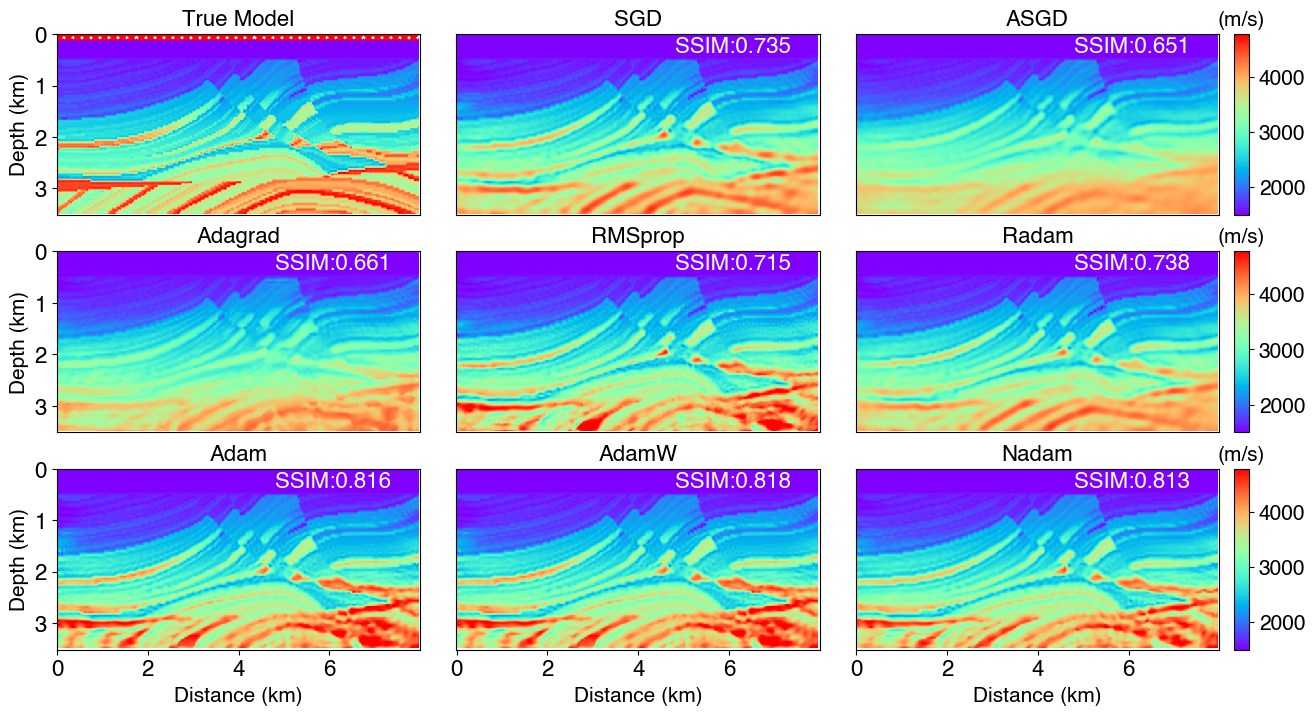

In [12]:
fig,axs = plt.subplots(3,3,figsize=(15,8))
im = plot_vel_single_for_all(fig,axs[0][0],true_v    ,title="True Model")

axs[0][0].scatter(rcv_x,rcv_z,c="w",marker="v",s=10)
axs[0][0].scatter(src_x,src_z,c="r",marker="*",s=60)
axs[0][0].set_ylabel("Depth (km)",fontsize=15)
axs[0][0].set_ylabel("Depth (km)",fontsize=15)

# plot_vel_single_for_all(fig,axs[0][1],init_v    ,title="Initial"        ,MSE="SSIM:{:.3f}".format(SSIM(true_v,init_v)))
plot_vel_single_for_all(fig,axs[0][1],sgd_v     ,title="SGD"            ,MSE="SSIM:{:.3f}".format(SSIM(true_v,sgd_v)))
plot_vel_single_for_all(fig,axs[0][2],asgd_v    ,title="ASGD"           ,MSE="SSIM:{:.3f}".format(SSIM(true_v,asgd_v)))
plot_vel_single_for_all(fig,axs[1][0],adagrad_v ,title="Adagrad"        ,MSE="SSIM:{:.3f}".format(SSIM(true_v,adagrad_v)))
plot_vel_single_for_all(fig,axs[1][1],rmsprop_v ,title="RMSprop"        ,MSE="SSIM:{:.3f}".format(SSIM(true_v,rmsprop_v)))
plot_vel_single_for_all(fig,axs[1][2],radam_v   ,title="Radam"          ,MSE="SSIM:{:.3f}".format(SSIM(true_v,radam_v)))
plot_vel_single_for_all(fig,axs[2][0],adam_v    ,title="Adam"           ,MSE="SSIM:{:.3f}".format(SSIM(true_v,adam_v)))
plot_vel_single_for_all(fig,axs[2][1],adamw_v   ,title="AdamW"          ,MSE="SSIM:{:.3f}".format(SSIM(true_v,adamw_v)))
plot_vel_single_for_all(fig,axs[2][2],nadam_v   ,title="Nadam"          ,MSE="SSIM:{:.3f}".format(SSIM(true_v,nadam_v)))

axs[0][0].set_ylabel("Depth (km)",fontsize=15)
axs[1][0].set_ylabel("Depth (km)",fontsize=15)
axs[2][0].set_ylabel("Depth (km)",fontsize=15)

axs[2][0].set_xlabel("Distance (km)",fontsize=15)
axs[2][1].set_xlabel("Distance (km)",fontsize=15)
axs[2][2].set_xlabel("Distance (km)",fontsize=15)

axs[0][0].set_xticks([])
axs[0][1].set_xticks([])
axs[0][2].set_xticks([])

axs[1][0].set_xticks([])
axs[1][1].set_xticks([])
axs[1][2].set_xticks([])

axs[0][1].set_yticks([])
axs[0][2].set_yticks([])
axs[1][1].set_yticks([])
axs[1][2].set_yticks([])
axs[2][1].set_yticks([])
axs[2][2].set_yticks([])

plt.subplots_adjust(hspace=0.2,wspace=0.1)

# colorbar
cax1 = add_right_cax(axs[0][2],pad=0.01,width=0.01)
cbar1 = fig.colorbar(im, cax=cax1)
cbar1.ax.set_title("(m/s)",fontsize=15,loc='center')
cbar1.ax.tick_params(labelsize=15)
cax2 = add_right_cax(axs[1][2],pad=0.01,width=0.01)
cbar2 = fig.colorbar(im, cax=cax2)
cbar2.ax.set_title("(m/s)",fontsize=15,loc='center')
cbar2.ax.tick_params(labelsize=15)
cax3 = add_right_cax(axs[2][2],pad=0.01,width=0.01)
cbar3 = fig.colorbar(im, cax=cax3)
cbar3.ax.set_title("(m/s)",fontsize=15,loc='center')
cbar3.ax.tick_params(labelsize=15)
# cax4 = add_right_cax(axs[3][2],pad=0.01,width=0.01)
# cbar4 = fig.colorbar(im, cax=cax4)
# cbar4.ax.set_title("(m/s)",fontsize=15,loc='center')
# cbar4.ax.tick_params(labelsize=15)

plt.savefig(os.path.join(base_path,"Optimizer_Model.png"),dpi=300,bbox_inches='tight')
plt.show()

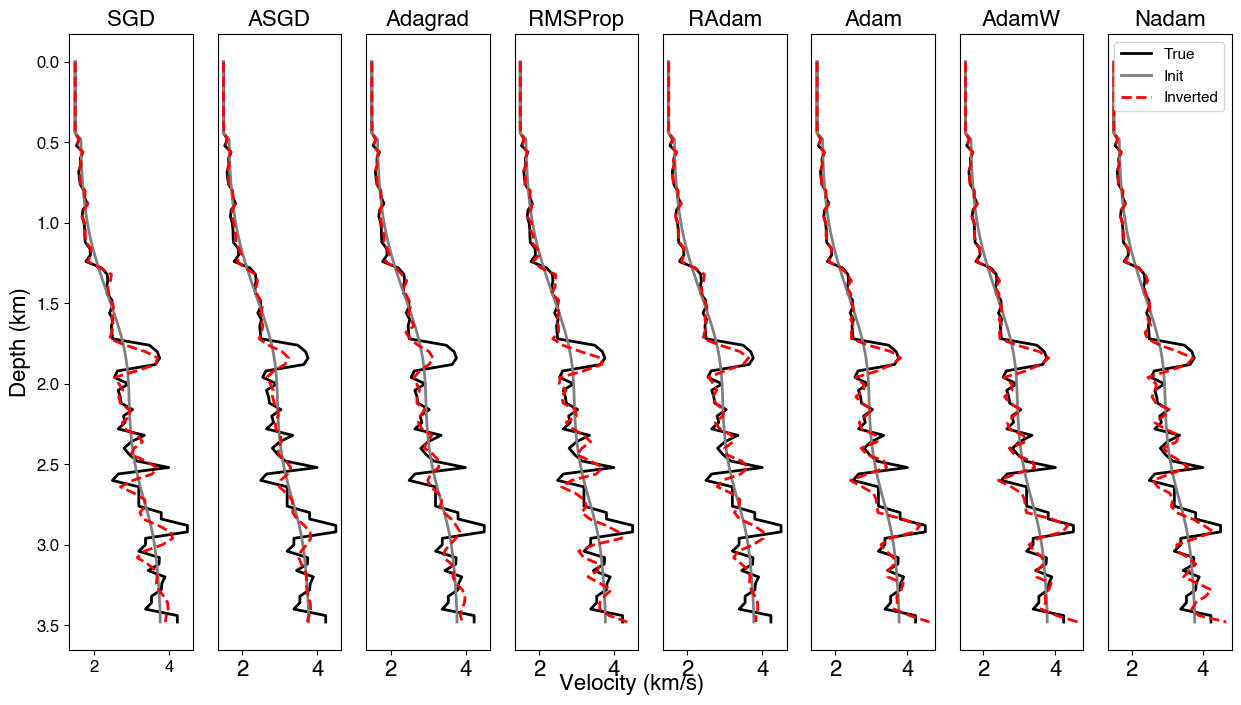

In [13]:
def plot_vel_singleline_for_all(ax,v_true,v_init,v_inv,x_distance,title,show_xlabel=True,show_ylabel=False,show_legend=False):
    ax.plot(v_true[:,int(x_distance//dx)]/1000,  z, c='k',   linewidth=2, linestyle="-" ,label="True")
    ax.plot(v_init[:,int(x_distance//dx)]/1000,  z, c='gray',linewidth=2, linestyle="-" ,label="Init")
    ax.plot(v_inv [:,int(x_distance//dx)]/1000,  z, c='r',   linewidth=2, linestyle="--",label="Inverted")
    ax.tick_params(labelsize = 16)
    if not show_xlabel:
        ax.set_xticks([])
    # else:
    #     ax.tick_params(labelsize = 15)
        
    if not show_ylabel:
        ax.set_yticks([])
    else:
        ax.tick_params(labelsize = 12)
    ax.invert_yaxis()
    
    if show_legend:
        ax.legend(fontsize = 11,loc='upper right')
    ax.set_title(title,fontsize=16)

fig,axs = plt.subplots(1,8,figsize=(15,8))
x_distance = 2500
plot_vel_singleline_for_all(axs[0],true_v,init_v,sgd_v      ,x_distance=x_distance,title=r"SGD", show_ylabel=True )
plot_vel_singleline_for_all(axs[1],true_v,init_v,asgd_v     ,x_distance=x_distance,title=r"ASGD", show_ylabel=False)
plot_vel_singleline_for_all(axs[2],true_v,init_v,adagrad_v  ,x_distance=x_distance,title=r"Adagrad", show_ylabel=False)
plot_vel_singleline_for_all(axs[3],true_v,init_v,rmsprop_v  ,x_distance=x_distance,title=r"RMSProp", show_ylabel=False)
plot_vel_singleline_for_all(axs[4],true_v,init_v,radam_v    ,x_distance=x_distance,title=r"RAdam", show_ylabel=False)
plot_vel_singleline_for_all(axs[5],true_v,init_v,adam_v     ,x_distance=x_distance,title=r"Adam", show_ylabel=False)
plot_vel_singleline_for_all(axs[6],true_v,init_v,adamw_v    ,x_distance=x_distance,title=r"AdamW", show_ylabel=False)
plot_vel_singleline_for_all(axs[7],true_v,init_v,nadam_v    ,x_distance=x_distance,title=r"Nadam", show_ylabel=False,show_legend=True)

axs[0].set_ylabel("Depth (km)",fontsize=16)
fig.text(0.5, 0.06, 'Velocity (km/s)', ha='center',fontsize=16)
plt.savefig(os.path.join(base_path,f"OptimizerTest-xdistance={x_distance}.png"),dpi=300,bbox_inches='tight')
plt.show()

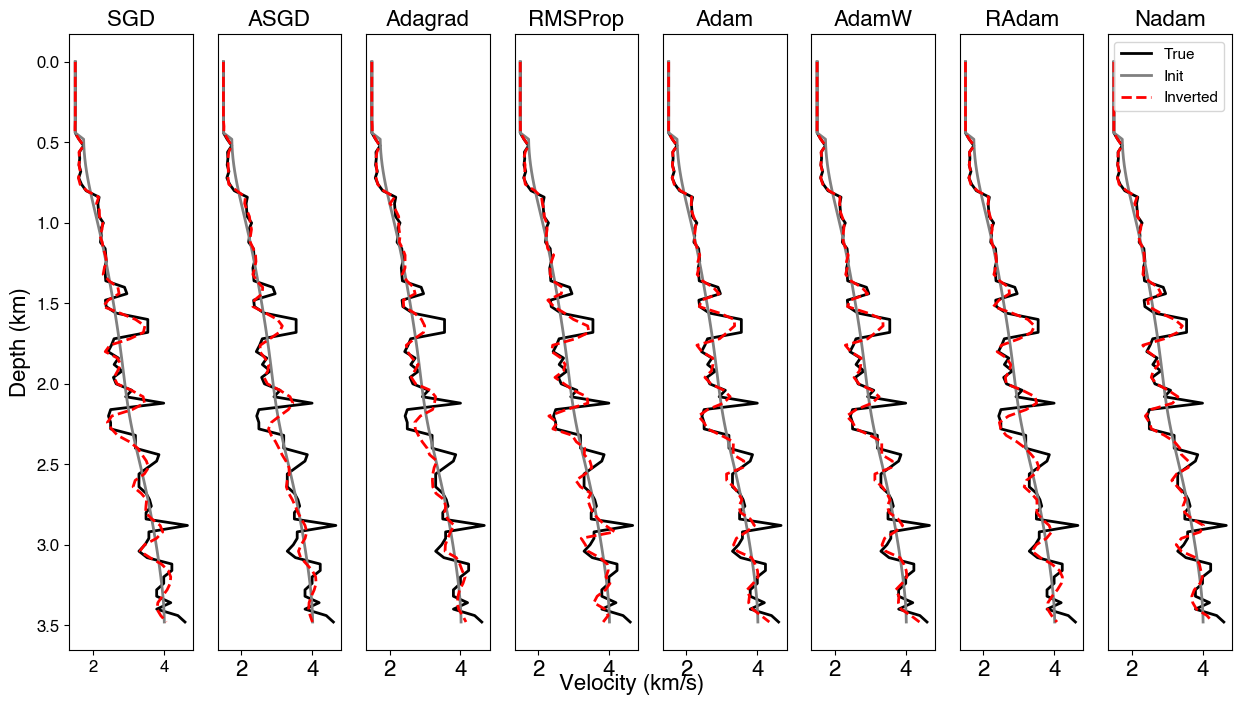

In [14]:
fig,axs = plt.subplots(1,8,figsize=(15,8))
x_distance = 4000
plot_vel_singleline_for_all(axs[0],true_v,init_v,sgd_v      ,x_distance=x_distance,title=r"SGD", show_ylabel=True )
plot_vel_singleline_for_all(axs[1],true_v,init_v,asgd_v     ,x_distance=x_distance,title=r"ASGD", show_ylabel=False)
plot_vel_singleline_for_all(axs[2],true_v,init_v,adagrad_v  ,x_distance=x_distance,title=r"Adagrad", show_ylabel=False)
plot_vel_singleline_for_all(axs[3],true_v,init_v,rmsprop_v  ,x_distance=x_distance,title=r"RMSProp", show_ylabel=False)
plot_vel_singleline_for_all(axs[4],true_v,init_v,adam_v     ,x_distance=x_distance,title=r"Adam", show_ylabel=False)
plot_vel_singleline_for_all(axs[5],true_v,init_v,adamw_v    ,x_distance=x_distance,title=r"AdamW", show_ylabel=False)
plot_vel_singleline_for_all(axs[6],true_v,init_v,radam_v    ,x_distance=x_distance,title=r"RAdam", show_ylabel=False)
plot_vel_singleline_for_all(axs[7],true_v,init_v,nadam_v    ,x_distance=x_distance,title=r"Nadam", show_ylabel=False,show_legend=True)

axs[0].set_ylabel("Depth (km)",fontsize=16)
fig.text(0.5, 0.06, 'Velocity (km/s)', ha='center',fontsize=16)
plt.savefig(os.path.join(base_path,f"OptimizerTest-xdistance={x_distance}.png"),dpi=300,bbox_inches='tight')
plt.show()

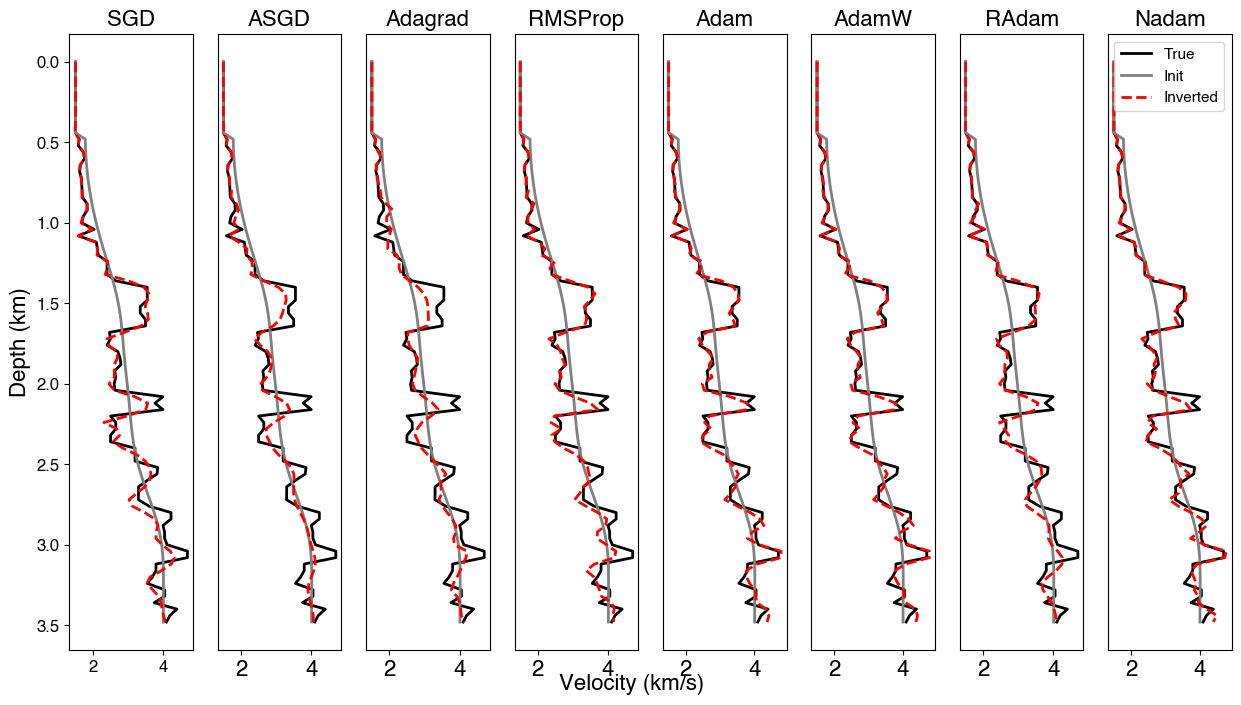

In [15]:
fig,axs = plt.subplots(1,8,figsize=(15,8))
x_distance = 5500
plot_vel_singleline_for_all(axs[0],true_v,init_v,sgd_v      ,x_distance=x_distance,title=r"SGD", show_ylabel=True )
plot_vel_singleline_for_all(axs[1],true_v,init_v,asgd_v     ,x_distance=x_distance,title=r"ASGD", show_ylabel=False)
plot_vel_singleline_for_all(axs[2],true_v,init_v,adagrad_v  ,x_distance=x_distance,title=r"Adagrad", show_ylabel=False)
plot_vel_singleline_for_all(axs[3],true_v,init_v,rmsprop_v  ,x_distance=x_distance,title=r"RMSProp", show_ylabel=False)
plot_vel_singleline_for_all(axs[4],true_v,init_v,adam_v     ,x_distance=x_distance,title=r"Adam", show_ylabel=False)
plot_vel_singleline_for_all(axs[5],true_v,init_v,adamw_v    ,x_distance=x_distance,title=r"AdamW", show_ylabel=False)
plot_vel_singleline_for_all(axs[6],true_v,init_v,radam_v    ,x_distance=x_distance,title=r"RAdam", show_ylabel=False)
plot_vel_singleline_for_all(axs[7],true_v,init_v,nadam_v    ,x_distance=x_distance,title=r"Nadam", show_ylabel=False,show_legend=True)

axs[0].set_ylabel("Depth (km)",fontsize=16)
fig.text(0.5, 0.06, 'Velocity (km/s)', ha='center',fontsize=16)
plt.savefig(os.path.join(base_path,f"OptimizerTest-xdistance={x_distance}.png"),dpi=300,bbox_inches='tight')
plt.show()